<a href="https://colab.research.google.com/github/Andrea-125478/MCD/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/BD proyecto anonimizado.xlsx')

print(df.head())

print(df.info())
print(df.describe())

   ID          SC        FIn  Anio_IC       Fter  TASA   Pl  \
0    1     ACTIVO 2023-01-04     2023 2025-12-31  26.0  156   
1    2  TERMINADO 2023-01-04     2023 2025-10-15  26.0  140   
2    3  TERMINADO 2023-01-04     2023 2026-01-03  26.0  156   
3    4     ACTIVO 2023-01-04     2023 2025-12-31  26.0  156   
4    5     ACTIVO 2023-01-11     2023 2026-01-07  26.0  156   

                 RE                          ZC   TM    Pt     CP  EC  \
0  UNIDAD RECUPERADA                    TIJUANA  ICE  UBER  22163  29   
1          TERMINADO                    TIJUANA  ICE  UBER  22216  29   
2          TERMINADO  CDMX Y AREA METROPOLITANA  ICE  UBER   9880  37   
3    CLIENTE VIGENTE  CDMX Y AREA METROPOLITANA  ICE  UBER  57500  26   
4    CLIENTE VIGENTE  CDMX Y AREA METROPOLITANA  ICE  UBER  55238  41   

         MFC      Md  KMEM  TOP   SV  IST  
0  291656.99  2023.0   NaN  NaN  2.0  NaN  
1  334216.32  2021.0   NaN  NaN  1.0  NaN  
2  306055.92  2023.0   NaN  NaN  NaN  NaN  
3  306

In [ ]:

mediana = df['IST'].median()


df['ISTmediana'] = df['IST'].fillna(mediana)

print("Mediana usada:", mediana)

Mediana usada: 7777.155


In [ ]:
print(df.head())

   ID          SC        FIn  Anio_IC       Fter  TASA   Pl  \
0    1     ACTIVO 2023-01-04     2023 2025-12-31  26.0  156   
1    2  TERMINADO 2023-01-04     2023 2025-10-15  26.0  140   
2    3  TERMINADO 2023-01-04     2023 2026-01-03  26.0  156   
3    4     ACTIVO 2023-01-04     2023 2025-12-31  26.0  156   
4    5     ACTIVO 2023-01-11     2023 2026-01-07  26.0  156   

                 RE                          ZC   TM  ...  EC        MFC  \
0  UNIDAD RECUPERADA                    TIJUANA  ICE  ...  29  291656.99   
1          TERMINADO                    TIJUANA  ICE  ...  29  334216.32   
2          TERMINADO  CDMX Y AREA METROPOLITANA  ICE  ...  37  306055.92   
3    CLIENTE VIGENTE  CDMX Y AREA METROPOLITANA  ICE  ...  26  306055.92   
4    CLIENTE VIGENTE  CDMX Y AREA METROPOLITANA  ICE  ...  41  261566.79   

       Md  KMEM  TOP   SV  IST  ISTmediana       ISTknn  Mdmoda  
0  2023.0   NaN  NaN  2.0  NaN    7777.155  7393.040857  2023.0  
1  2021.0   NaN  NaN  1.0  NaN  

In [ ]:
from sklearn.impute import KNNImputer


variables = df[['IST', 'EC', 'MFC']]


imputer = KNNImputer(n_neighbors=5)


variables_imputadas = imputer.fit_transform(variables)

df_knn = pd.DataFrame(variables_imputadas, columns=variables.columns)

df['ISTknn'] = df_knn['IST']

print(df[['IST', 'ISTmediana', 'ISTknn']].head())

   IST  ISTmediana       ISTknn
0  NaN    7777.155  7393.040857
1  NaN    7777.155  8104.492250
2  NaN    7777.155  7867.317048
3  NaN    7777.155  7867.317048
4  NaN    7777.155  8479.842333


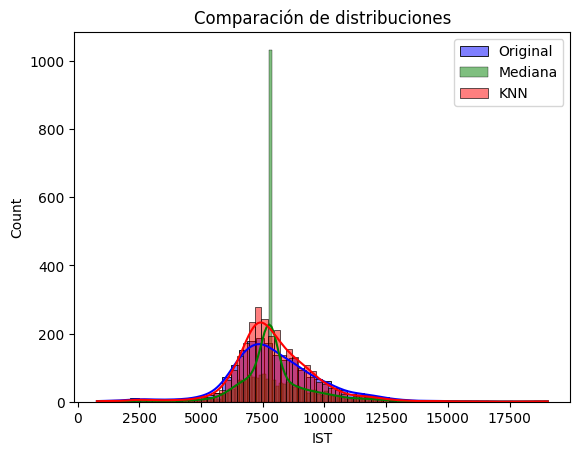

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma original vs imputado con mediana vs KNN
sns.histplot(df['IST'], color='blue', label='Original', kde=True)
sns.histplot(df['ISTmediana'], color='green', label='Mediana', kde=True)
sns.histplot(df['ISTknn'], color='red', label='KNN', kde=True)

plt.legend()
plt.title("Comparación de distribuciones")
plt.show()

In [ ]:

df.to_excel('ISPimputados.xlsx', index=False)

print("Archivo guardado como datos_imputados.xlsx")

Archivo guardado como datos_imputados.xlsx


In [ ]:

moda = df['Md'].mode()[0]
df['Md'] = df['Md'].fillna(moda)

In [4]:
import pandas as pd

df = pd.read_excel('/content/ISPimputados.xlsx')


print(df.head())

print(df.info())
print(df.describe())

   ID          SC        FIn  Anio_IC       Fter  TASA   Pl  \
0    1     ACTIVO 2023-01-04     2023 2025-12-31  26.0  156   
1    2  TERMINADO 2023-01-04     2023 2025-10-15  26.0  140   
2    3  TERMINADO 2023-01-04     2023 2026-01-03  26.0  156   
3    4     ACTIVO 2023-01-04     2023 2025-12-31  26.0  156   
4    5     ACTIVO 2023-01-11     2023 2026-01-07  26.0  156   

                 RE                          ZC   TM    Pt     CP  EC  \
0  UNIDAD RECUPERADA                    TIJUANA  ICE  UBER  22163  29   
1          TERMINADO                    TIJUANA  ICE  UBER  22216  29   
2          TERMINADO  CDMX Y AREA METROPOLITANA  ICE  UBER   9880  37   
3    CLIENTE VIGENTE  CDMX Y AREA METROPOLITANA  ICE  UBER  57500  26   
4    CLIENTE VIGENTE  CDMX Y AREA METROPOLITANA  ICE  UBER  55238  41   

         MFC      Md  KMEM  TOP   SV       ISTknn  
0  291656.99  2023.0   NaN  NaN  2.0  7393.040857  
1  334216.32  2021.0   NaN  NaN  1.0  8104.492250  
2  306055.92  2023.0   NaN

In [5]:


moda = df['Md'].mode()[0]
df['Md'] = df['Md'].fillna(moda)

In [6]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2859 entries, 0 to 2858
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   ID       2859 non-null   int64         
 1   SC       2859 non-null   object        
 2   FIn      2859 non-null   datetime64[ns]
 3   Anio_IC  2859 non-null   int64         
 4   Fter     2859 non-null   datetime64[ns]
 5   TASA     2859 non-null   float64       
 6   Pl       2859 non-null   int64         
 7   RE       2859 non-null   object        
 8   ZC       2859 non-null   object        
 9   TM       2859 non-null   object        
 10  Pt       2859 non-null   object        
 11  CP       2859 non-null   int64         
 12  EC       2859 non-null   int64         
 13  MFC      2859 non-null   float64       
 14  Md       2859 non-null   float64       
 15  KMEM     0 non-null      float64       
 16  TOP      0 non-null      float64       
 17  SV       1332 non-null   float64 

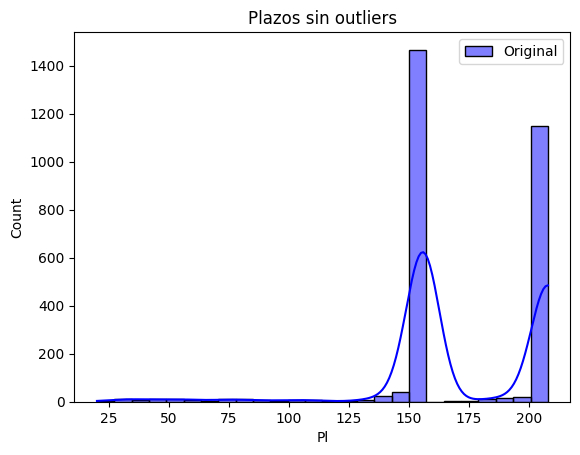

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.histplot(df['Pl'], color='blue', label='Original', kde=True)


plt.legend()
plt.title("Plazos sin outliers")
plt.show()

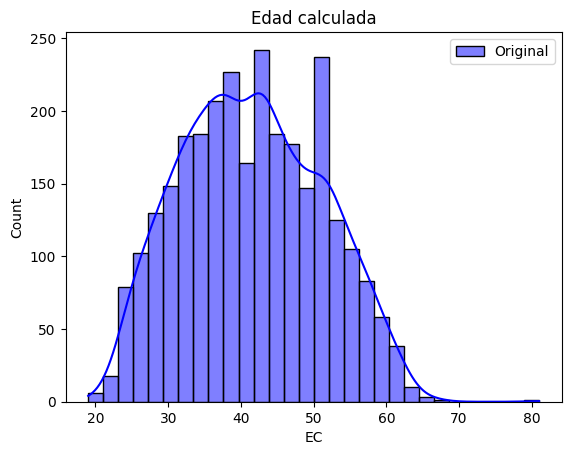

In [ ]:
sns.histplot(df['EC'], color='blue', label='Original', kde=True)


plt.legend()
plt.title("Edad calculada")
plt.show()

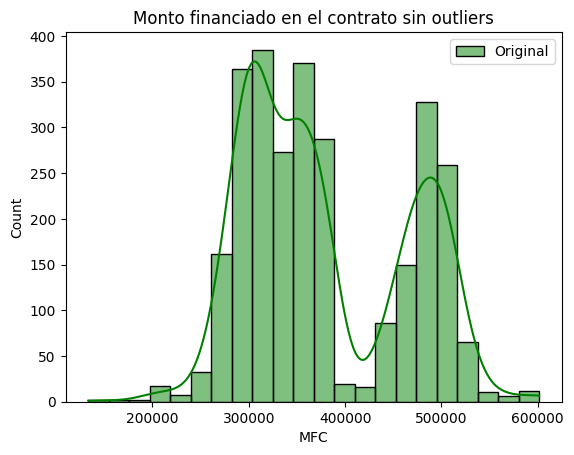

In [ ]:
sns.histplot(df['MFC'], color='green', label='Original', kde=True)


plt.legend()
plt.title("Monto financiado en el contrato sin outliers")
plt.show()

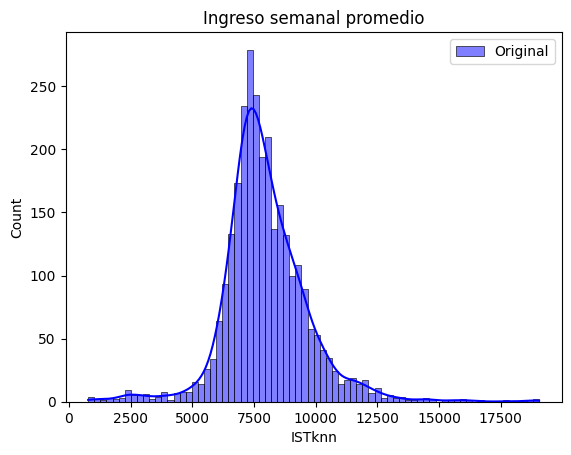

In [ ]:
sns.histplot(df['ISTknn'], color='blue', label='Original', kde=True)


plt.legend()
plt.title("Ingreso semanal promedio")
plt.show()

In [ ]:
df.columns = df.columns.str.strip()
indices = df[df['ID'] == 1947].index
print(indices)

Index([1946], dtype='int64')


In [7]:

df.drop(index=327, inplace=True)

In [8]:
print(df.describe())

               ID                             FIn      Anio_IC  \
count  2858.000000                           2858  2858.000000   
mean   1430.385584  2024-09-18 17:49:10.034989824  2024.242827   
min       1.000000            2023-01-04 00:00:00  2023.000000   
25%     716.250000            2024-04-13 12:00:00  2024.000000   
50%    1430.500000            2024-10-31 00:00:00  2024.000000   
75%    2144.750000            2025-04-25 00:00:00  2025.000000   
max    2859.000000            2025-08-08 00:00:00  2025.000000   
std     825.353433                            NaN     0.733106   

                                Fter         TASA           Pl            CP  \
count                           2858  2858.000000  2858.000000   2858.000000   
mean   2027-10-29 10:22:15.199440128    29.284727   173.521344  34912.102869   
min              2023-07-14 00:00:00    26.000000     3.000000   1110.000000   
25%              2026-12-09 00:00:00    28.750000   156.000000  10300.000000   
50%  

In [9]:
df.drop(index=[2109, 2759, 747,858], inplace=True)


In [10]:
df.drop(index=[1947], inplace=True)


In [11]:
print(df.describe())

               ID                             FIn      Anio_IC  \
count  2853.000000                           2853  2853.000000   
mean   1429.939362  2024-09-18 19:45:36.908517376  2024.242902   
min       1.000000            2023-01-04 00:00:00  2023.000000   
25%     715.000000            2024-04-18 00:00:00  2024.000000   
50%    1430.000000            2024-10-31 00:00:00  2024.000000   
75%    2145.000000            2025-04-25 00:00:00  2025.000000   
max    2859.000000            2025-08-08 00:00:00  2025.000000   
std     825.378001                            NaN     0.733077   

                                Fter         TASA           Pl            CP  \
count                           2853  2853.000000  2853.000000   2853.000000   
mean   2027-10-31 08:27:15.331230464    29.284437   173.807921  34933.953032   
min              2023-07-14 00:00:00    26.000000    20.000000   1110.000000   
25%              2026-12-09 00:00:00    28.750000   156.000000  10300.000000   
50%  

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Plz'] = scaler.fit_transform(df[['Pl']])

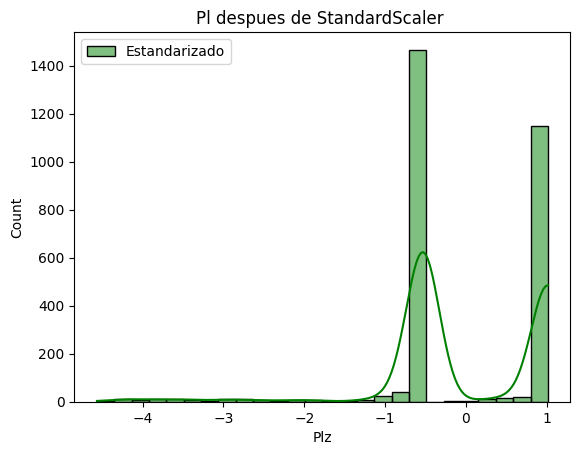

In [ ]:
#sns.histplot(df['Pl'], color='blue', label='Original', kde=True)
sns.histplot(df['Plz'], color='green', label='Estandarizado', kde=True)

plt.legend()
plt.title("Pl despues de StandardScaler ")
plt.show()

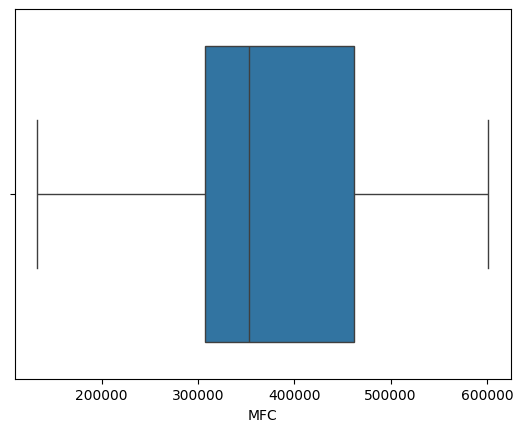

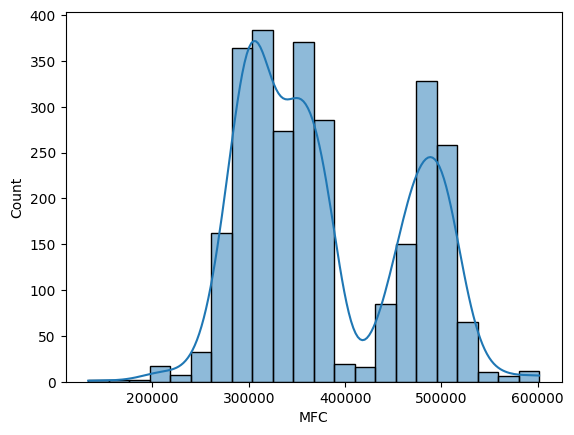

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot
sns.boxplot(x=df['MFC'])
plt.show()

# Histograma
sns.histplot(df['MFC'], kde=True)
plt.show()

In [ ]:
from scipy import stats

z_scores = stats.zscore(df['MFC'])
outliers = df[(abs(z_scores) > 3)]  # valores con |z| > 3 suelen ser outliers fuertes
print(outliers)

Empty DataFrame
Columns: [ID, SC, FIn, Anio_IC, Fter, TASA, Pl, RE, ZC, TM, Pt, CP, EC, MFC, Md, KMEM, TOP, SV, ISTknn, Plz]
Index: []


In [13]:
scaler = StandardScaler()
df['MFCZ'] = scaler.fit_transform(df[['MFC']])

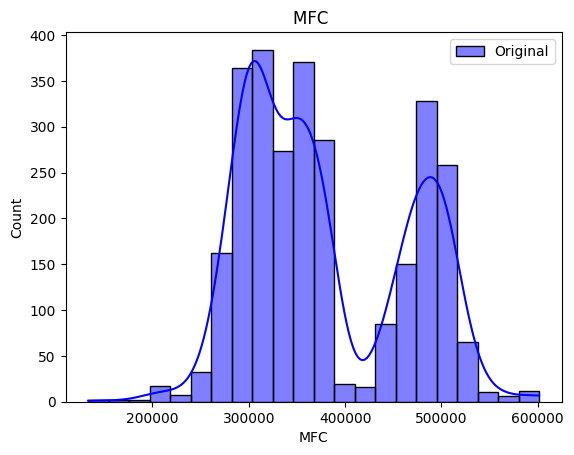

In [ ]:
sns.histplot(df['MFC'], color='blue', label='Original', kde=True)
#sns.histplot(df['MFCZ'], color='green', label='Estandarizado', kde=True)

plt.legend()
plt.title("MFC ")
plt.show()

In [14]:

df.to_excel('M2.xlsx', index=False)


Archivo guardado como datos_imputados.xlsx


In [3]:
import pandas as pd

df = pd.read_excel('/content/M2 (1).xlsx
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2853 entries, 0 to 2852
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ID          2853 non-null   int64         
 1   SC          2853 non-null   object        
 2   Unnamed: 2  2853 non-null   object        
 3   FIn         2853 non-null   datetime64[ns]
 4   Fter        2853 non-null   datetime64[ns]
 5   TASA        2853 non-null   float64       
 6   ZC          2853 non-null   object        
 7   TM          2853 non-null   object        
 8   Pt          2853 non-null   object        
 9   CP          2853 non-null   int64         
 10  EC          2853 non-null   int64         
 11  Md          2853 non-null   int64         
 12  TOP         0 non-null      float64       
 13  ISPknn      2853 non-null   float64       
 14  Plz         2853 non-null   float64       
 15  MFCZ        2853 non-null   float64       
dtypes: datetime64[ns](2), fl


```
2110 2109
2760 2759
748 747
1948 2947
859 858
```
